In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset('CTSM_DATM_JP-Yoy_2006-2020.nc')
ds

<xarray.Dataset> Size: 14MB
Dimensions:                             (time: 124887, y: 1, x: 1)
Coordinates:
  * time                                (time) datetime64[ns] 999kB 2006-01-0...
  * x                                   (x) int64 8B 1
  * y                                   (y) int64 8B 1
Data variables: (12/50)
    Prectmms                            (time, y, x) float64 999kB ...
    Wind                                (time, y, x) float64 999kB ...
    Zbot                                (time, x, y) float64 999kB ...
    LWdown                              (time, y, x) float64 999kB ...
    LWdown_qc                           (time) int8 125kB ...
    PSurf                               (time, y, x) float64 999kB ...
    ...                                  ...
    topsoil_clay_fraction               (y, x) float64 8B ...
    topsoil_sand_fraction               (y, x) float64 8B ...
    tree_area_fraction                  (y, x) float64 8B ...
    tree_mean_height                    (y, x) float64 8B ...
    wall_to_plan_area_ratio             (y, x) float64 8B ...
    water_area_fraction                 (y, x) float64 8B ...
Attributes: (12/24)
    title:                      URBAN-PLUMBER forcing data for JP-Yoyogi
    summary:                    Observed and ERA5-derived surface meteorologi...
    sitename:                   JP-Yoyogi
    long_sitename:              Yoyogi, Tokyo, Japan
    version:                    v1
    conventions:                ALMA+CF.rev13
    ...                         ...
    date_created:               2021-05-27 12:16:22
    other_references:           ERA5: Copernicus Climate Change Service (C3S)...
    acknowledgements:           Contains modified Copernicus Climate Change S...
    comment:                    Observations for turbulent fluxes removed fro...
    history:                    Thu May 27 09:03:05 2021: ncatted -a calendar...
    NCO:                        netCDF Operators version 4.7.9 (Homepage = ht...

In [3]:
vars = ['Tair', 'Qair', 'SWdown', 'LWdown', 'Prectmms', 'Wind', 'PSurf']
ylabel = ['TBOT [K]', 'QBOT [kg/kg]', 'SWDOWN [W/m2]', 'LWDOWN [W/m2]', 'PRECP [mm/s]', 'WIND [m/s]', 'PBOT [Pa]']
columns = {
    vars[i]: ylabel[i] for i in range(len(vars))
}

In [4]:
df = ds[vars].to_dataframe()
df.describe().rename(columns=columns).round(2)

,TBOT [K],QBOT [kg/kg],SWDOWN [W/m2],LWDOWN [W/m2],PRECP [mm/s],WIND [m/s],PBOT [Pa]
count,124887.00,124887.00,124887.00,124887.00,124887.00,124887.00,124887.00
mean,289.27,0.01,156.37,350.64,0.00,3.75,101084.82
std,8.38,0.01,233.86,61.69,0.00,2.26,717.99
min,269.75,0.00,0.00,201.37,0.00,0.00,96480.84
25%,281.96,0.00,0.00,300.99,0.00,2.19,100606.22
50%,289.56,0.01,6.53,353.76,0.00,3.28,101084.61
75%,296.07,0.01,261.55,404.65,0.00,4.79,101592.68
max,311.13,0.02,1030.56,483.39,0.01,25.40,103380.00


In [5]:
df = df.reset_index()
df['month'] = df['time'].dt.month
df.groupby('month').mean().round(2)['Tair']-273.15

month
1      5.46
2      6.30
3      9.63
4     14.27
5     19.42
6     22.26
7     26.26
8     27.73
9     23.88
10    18.57
11    12.91
12     8.01
Name: Tair, dtype: float64

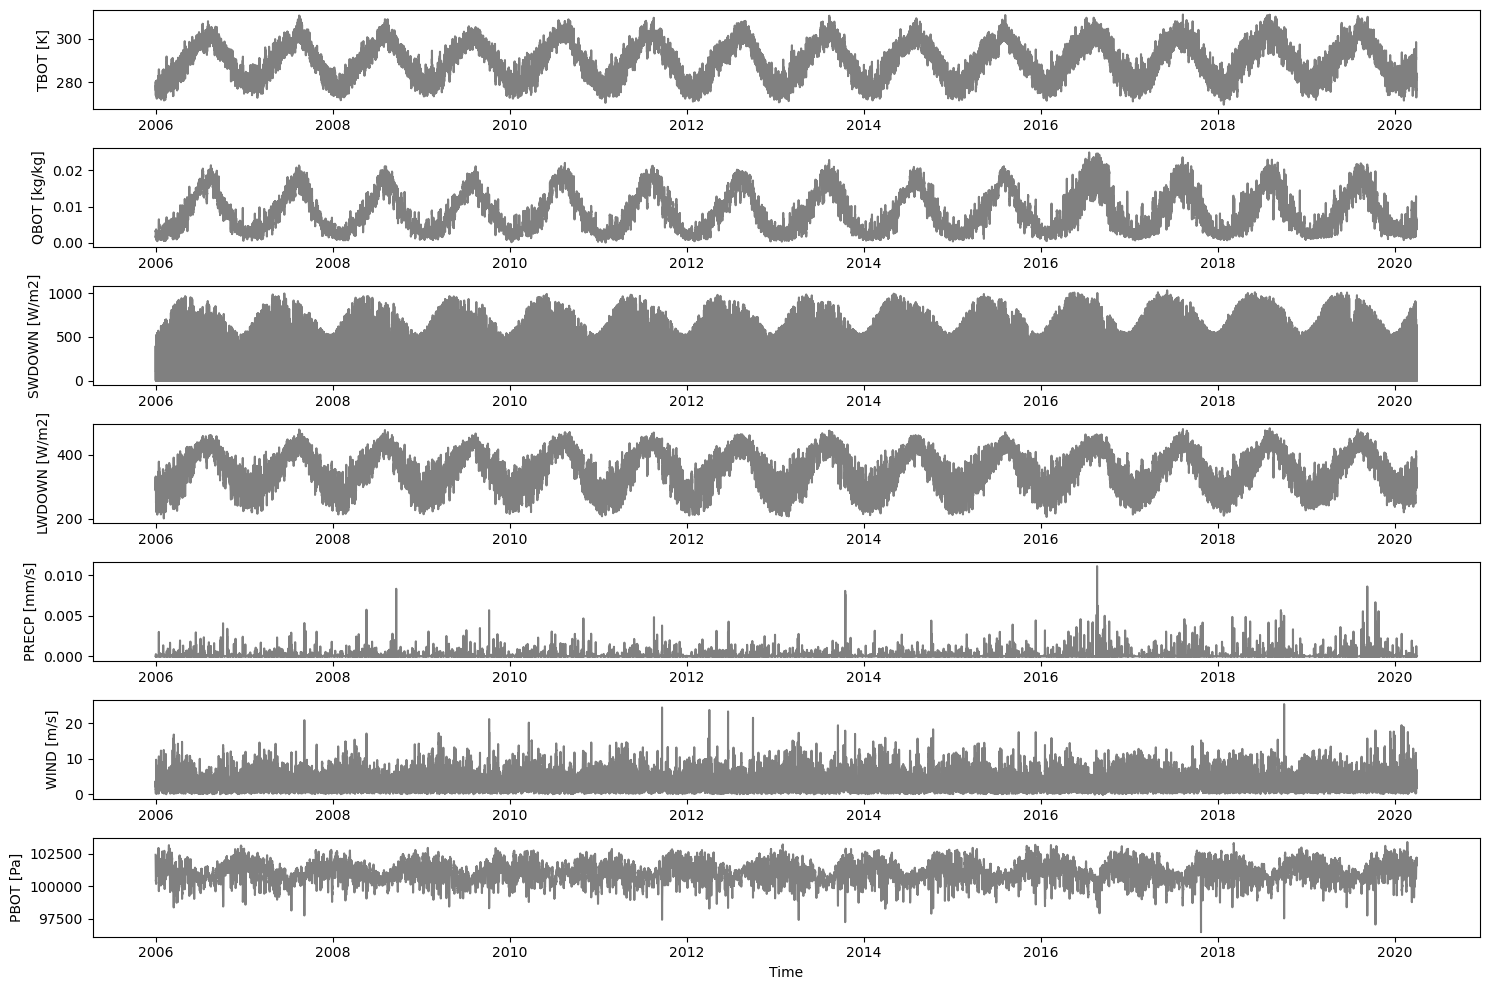

In [6]:

fig = plt.figure(figsize=(15, 10))
i=1
for var in vars:
    ax = fig.add_subplot(len(vars), 1, i)
    ds[var].plot(ax=ax, color='gray')
    ax.set_ylabel(ylabel[i-1])
    ax.set_title('')
    ax.set_xlabel('')
    i += 1
ax.set_xlabel('Time')
plt.tight_layout()
plt.savefig('./figs/forcing_data.pdf', bbox_inches='tight', dpi=300)
plt.show()